# Exploratory data analysis of findings

This notebook explores the implications of these findings in cancerous tissue specimens.

## 0. Initializations

In [1]:
## 0. Initializations
# -- imports --
import matplotlib.pyplot as plt
import seaborn as sns

from signals_in_the_noise.preprocessing.gse161529 import GSE161529

In [2]:
# -- datasets --
gse = GSE161529()

In [3]:
# noise subtype classification is applied internally by aggregate_noise_subtypes_by_cancer_type

## 1. Apply findings

Apply findings to tissue specimens that are classified as from "Total" cell population and explore.

In [22]:
from signals_in_the_noise.analysis.noise_phenotypes import aggregate_noise_subtypes_by_cancer_type, \
    DEFAULT_PBS_THRESHOLDS
from signals_in_the_noise.analysis.noise_phenotypes import PbsThresholds, Thresholds

pbs_1_thresholds = PbsThresholds(
    pct_counts_mt=Thresholds(q_low=0.85, q_high=None, q_mod_low=None, q_mod_high=None),
    # log1p_total_counts=Thresholds(q_low=None, q_high=0.3, q_mod_low=None, q_mod_high=None),
    log1p_total_counts=Thresholds(q_low=None, q_high=0.5, q_mod_low=None, q_mod_high=None),
    log1p_n_genes_by_counts=Thresholds(q_low=None, q_high=0.3, q_mod_low=None, q_mod_high=None),
)
pbs_2_thresholds = PbsThresholds(
    pct_counts_mt=Thresholds(q_low=None, q_high=0.25, q_mod_low=None, q_mod_high=None),
    log1p_total_counts=Thresholds(q_low=None, q_high=0.3, q_mod_low=None, q_mod_high=None),
    log1p_n_genes_by_counts=Thresholds(q_low=None, q_high=None, q_mod_low=0.45, q_mod_high=0.85),
)
pbs_3_thresholds = PbsThresholds(
    pct_counts_mt=Thresholds(q_low=None, q_high=None, q_mod_low=0.3, q_mod_high=0.65),
    log1p_total_counts=Thresholds(q_low=None, q_high=None, q_mod_low=0.5, q_mod_high=0.85),
    log1p_n_genes_by_counts=Thresholds(q_low=0.95, q_high=None, q_mod_low=None, q_mod_high=None),
)

# pbs_1_thresholds = PbsThresholds(
#     pct_counts_mt=Thresholds(q_low=0.9, q_high=None, q_mod_low=None, q_mod_high=None),
#     log1p_total_counts=Thresholds(q_low=None, q_high=None, q_mod_low=0.1, q_mod_high=0.25),
#     log1p_n_genes_by_counts=Thresholds(q_low=None, q_high=0.25, q_mod_low=None, q_mod_high=None),
# )
# pbs_2_thresholds = PbsThresholds(
#     pct_counts_mt=Thresholds(q_low=None, q_high=0.15, q_mod_low=None, q_mod_high=None),
#     log1p_total_counts=Thresholds(q_low=None, q_high=None, q_mod_low=0.1, q_mod_high=0.25),
#     log1p_n_genes_by_counts=Thresholds(q_low=None, q_high=None, q_mod_low=0.40, q_mod_high=0.65),
# )
# pbs_3_thresholds = PbsThresholds(
#     pct_counts_mt=Thresholds(q_low=None, q_high=None, q_mod_low=0.25, q_mod_high=0.55),
#     log1p_total_counts=Thresholds(q_low=0.45, q_high=None, q_mod_low=None, q_mod_high=None),
#     log1p_n_genes_by_counts=Thresholds(q_low=0.7, q_high=None, q_mod_low=None, q_mod_high=None),
# )

potential_signals_norm_df = aggregate_noise_subtypes_by_cancer_type(
    list(gse.objects.values()), pbs_thresholds={
        "pbs-1": pbs_1_thresholds,
        "pbs-2": pbs_2_thresholds,
        "pbs-3": pbs_3_thresholds,
})

# potential_signals_norm_df = aggregate_noise_subtypes_by_cancer_type(
#     list(gse.objects.values()), pbs_thresholds=DEFAULT_PBS_THRESHOLDS
# )

In [23]:
# aggregation and normalisation handled by aggregate_noise_subtypes_by_cancer_type above

In [24]:
# normalisation handled by aggregate_noise_subtypes_by_cancer_type above

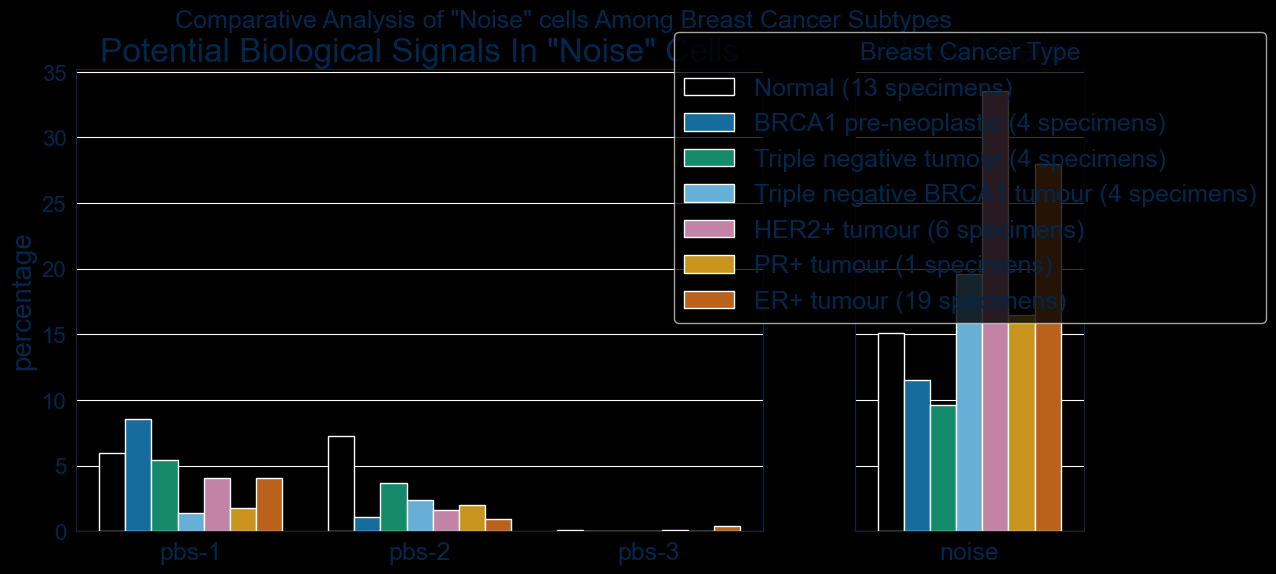

In [25]:
from signals_in_the_noise.utils.visualization import plot_noise_subtype_comparison

palette_a = [
    "#000000",  # cat 1 — black (anchor)
    "#0072B2",  # cat 2 — blue
    "#009E73",  # cat 3 — bluish green
    "#56B4E9",  # cat 4 — sky blue
    "#CC79A7",  # cat 5 — reddish purple
    "#E69F00",  # cat 6 — yellow-orange
    "#D55E00",  # cat 7 — vermillion (anchor)
]

sns.set_palette(palette_a)

ax_1, ax_2 = plot_noise_subtype_comparison(potential_signals_norm_df)

In [26]:
# real_count, noise_count

In [27]:
# noise_count/real_count

## 2. Publication figure

Uses `potential_signals_norm_df` from `aggregate_noise_subtypes_by_cancer_type` (PBS subtypes counted among noise cells only), with publication styling below.

In [28]:
# Publication figure below uses potential_signals_norm_df from
# aggregate_noise_subtypes_by_cancer_type (noise-only PBS counting).


In [29]:
# (removed manual per-cell classification — counts come from aggregate_noise_subtypes_by_cancer_type)

In [30]:
# (removed manual aggregation — counts come from aggregate_noise_subtypes_by_cancer_type)

In [31]:
# (removed manual count table — see potential_signals_norm_df above)

In [32]:
# Do not overwrite potential_signals_norm_df — normalization is already correct
# from aggregate_noise_subtypes_by_cancer_type (noise-only PBS counts).

In [33]:
# prepare data for publication figure — long form from correct aggregate output
long_form_potential_signals_df = potential_signals_norm_df[['pbs-1', 'pbs-2', 'pbs-3']].reset_index()
long_form_potential_signals_df.columns.values[0] = 'cancer type'
long_form_potential_signals_df = long_form_potential_signals_df.melt(
    id_vars='cancer type',
    var_name='potential signal',
    value_name='percentage of noise',
)

long_form_noise_df = potential_signals_norm_df['noise'].reset_index()
long_form_noise_df.columns.values[0] = 'cancer type'
long_form_noise_df = long_form_noise_df.melt(
    id_vars='cancer type',
    var_name='potential signal',
    value_name='percentage of cells',
)

In [34]:
cancer_types = long_form_potential_signals_df['cancer type'].unique()
idx_normal = 0
idx_pre = 1
cancer_types

array(['Normal (13 specimens)', 'BRCA1 pre-neoplastic (4 specimens)',
       'Triple negative tumour (4 specimens)',
       'Triple negative BRCA1 tumour (4 specimens)',
       'HER2+ tumour (6 specimens)', 'PR+ tumour (1 specimens)',
       'ER+ tumour (19 specimens)'], dtype=object)

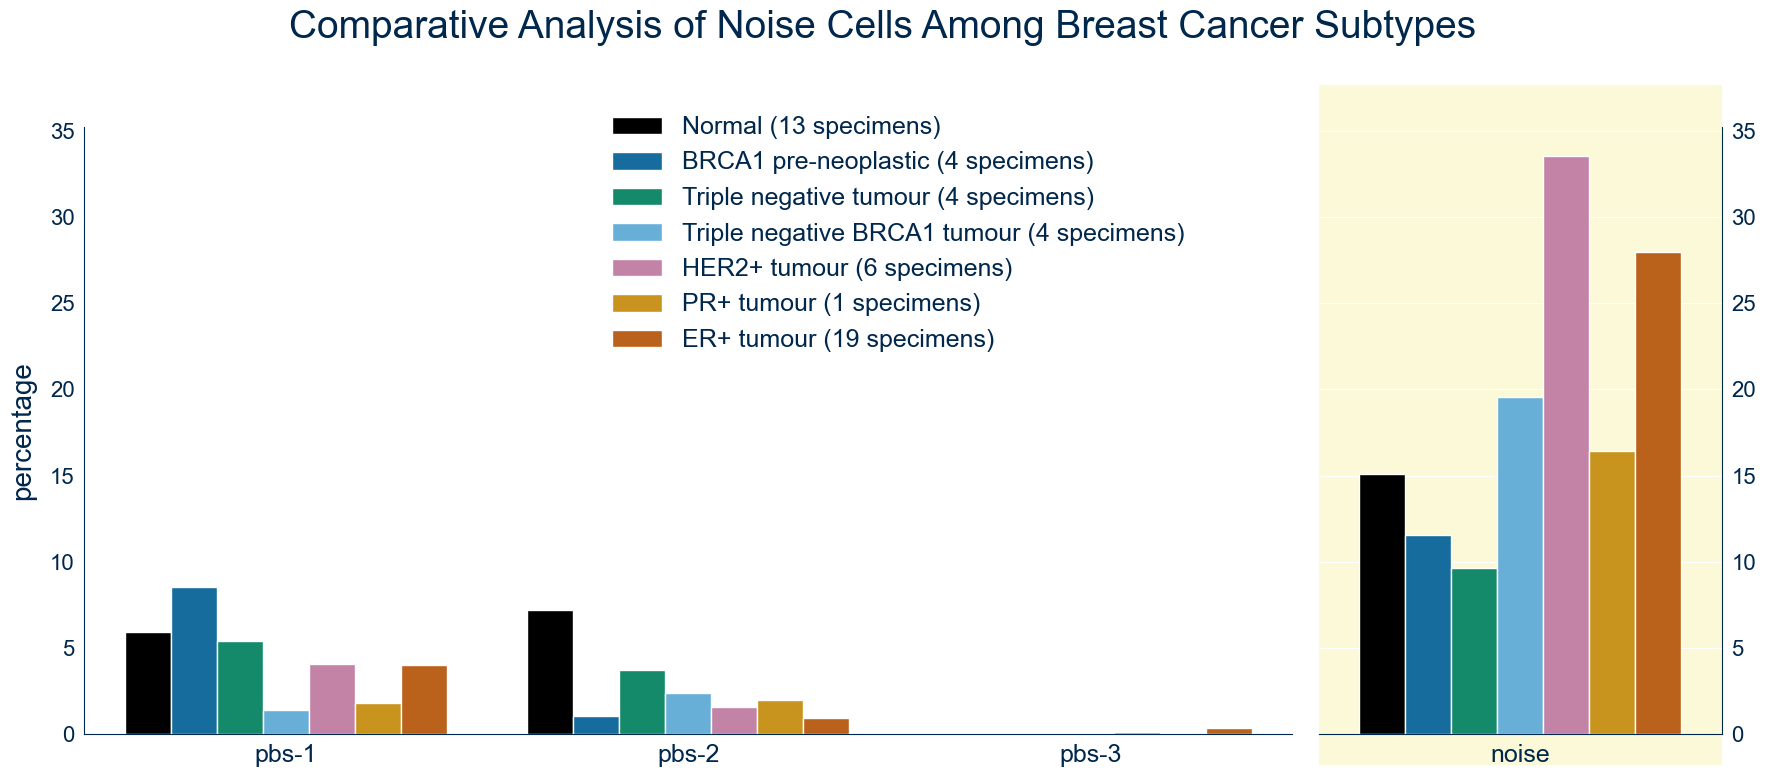

In [35]:
font_color = '#00274C'

plt.rcParams.update({
    'text.color': font_color,
    'axes.labelcolor': font_color,
    'axes.edgecolor': font_color,
    'xtick.labelcolor': font_color,
    'ytick.labelcolor': font_color,
    'font.size': 18,          # base font size
    'axes.titlesize': 24,     # subplot titles
    'axes.labelsize': 20,     # x/y labels
    'xtick.labelsize': 18,    # x tick labels
    'ytick.labelsize': 16,    # y tick labels
    'legend.title_fontsize': 18,
    'legend.fontsize': 18,
    'figure.titlesize': 28    # main title
})

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18,8), gridspec_kw={'width_ratios': [3,1]}, sharey=True)
sns.barplot(data=long_form_potential_signals_df, x='potential signal', y='percentage of noise', hue='cancer type', ax=ax1, palette=palette_a)
# ax1.set_title('Potential Biological Signals In "Noise" Cells')
ax1.set_xlabel('')
ax1.set_ylabel('percentage', labelpad=10)
ax1.get_legend().remove()

sns.barplot(data=long_form_noise_df, x='potential signal', y='percentage of cells', hue='cancer type', ax=ax2, palette=palette_a)
# ax2.set_title('"Noise" Cells')
ax2.set_xlabel('')
ax2.set_ylabel('percentage', labelpad=10)
ax2.get_legend().remove()

for ax in [ax1, ax2]:
    ax.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)
ax2.spines['left'].set_visible(False)

ax2.tick_params(axis='y', which='both', right=True, labelright=True)
ax2.yaxis.set_ticks_position('right')
ax2.yaxis.set_label_position("right")      # move label to right

import matplotlib.patches as patches
rect = patches.Rectangle(
    (0, -0.05), 1, 1.12,           # slightly extend beyond top
    transform=ax2.transAxes,
    color='#F4EE7B',
    alpha=0.3,
    zorder=-1,
    lw=0,
    clip_on=False                   # allow rectangle to spill outside
)
ax2.add_patch(rect)

handles, labels = ax1.get_legend_handles_labels()
fig.legend(handles, labels, loc='center right', bbox_to_anchor=(0.68, 0.7), frameon=False)
fig.patch.set_alpha(0)
for ax in fig.axes:
    ax.set_facecolor("none")
plt.suptitle('Comparative Analysis of Noise Cells Among Breast Cancer Subtypes')
plt.tight_layout()

from pathlib import Path
figure_path = Path('../images/iscb-scs-figure-2.png')
figure_path.parent.mkdir(parents=True, exist_ok=True)
plt.savefig(figure_path, bbox_inches='tight', dpi=300, transparent=True)

In [36]:
# long_form_noise_df[long_form_noise_df['cancer type']==cancer_types[0]]

In [37]:
# long_form_noise_df[long_form_noise_df['cancer type']==cancer_types[6]]

In [38]:
# long_form_potential_signals_df[long_form_potential_signals_df['cancer type']==cancer_types[0]]

In [39]:
# long_form_potential_signals_df[long_form_potential_signals_df['cancer type']==cancer_types[6]]